In [ ]:
!rm /content/handset.zip

rm: cannot remove '/content/handset.zip': No such file or directory


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d gulerosman/hg14-handgesture14-dataset -p /content

Dataset URL: https://www.kaggle.com/datasets/gulerosman/hg14-handgesture14-dataset
License(s): ODbL-1.0
100% 232M/232M [00:12<00:00, 18.8MB/s]



In [ ]:
!unzip -q /content/hg14-handgesture14-dataset.zip -d /content/HG14

In [ ]:
!find /content/HG14 -type f | head -20

/content/HG14/HG14/Read.docx
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2819.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2687.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2712.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2120.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2159.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2542.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2439.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2091.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2209.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2937.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2109.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2528.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2155.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2771.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2032.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2278.jpg
/content/HG14/HG14/HG14-Hand Gesture/Gesture_2/2396.jpg
/content/HG14/HG14/

In [ ]:
import os

dataset_path = "/content/HG14/HG14/HG14-Hand Gesture"

for gesture in sorted(os.listdir(dataset_path)):
    gesture_path = os.path.join(dataset_path, gesture)

    if os.path.isdir(gesture_path):
        images = [
            f for f in os.listdir(gesture_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        print(f"{gesture}: {len(images)} images")

Gesture_0: 1000 images
Gesture_1: 1000 images
Gesture_10: 1000 images
Gesture_11: 1000 images
Gesture_12: 1000 images
Gesture_13: 1000 images
Gesture_2: 1000 images
Gesture_3: 1000 images
Gesture_4: 1000 images
Gesture_5: 1000 images
Gesture_6: 1000 images
Gesture_7: 1000 images
Gesture_8: 1000 images
Gesture_9: 1000 images


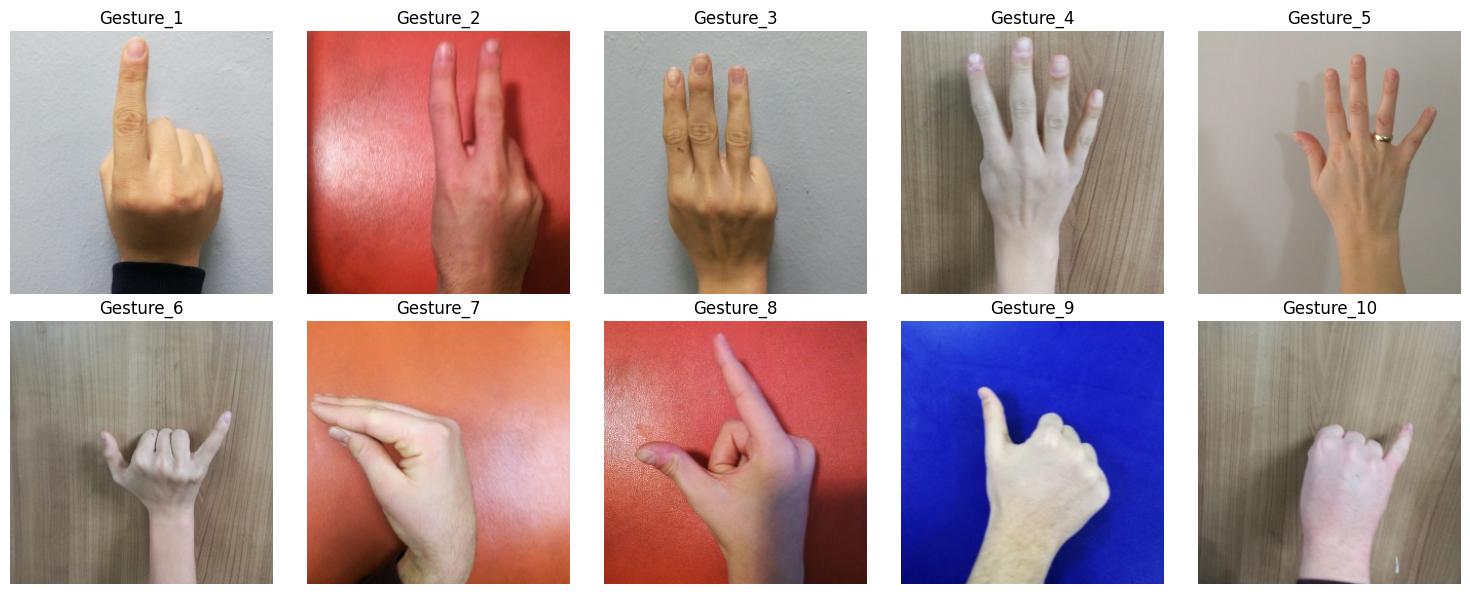

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    gesture = f"Gesture_{i+1}"
    folder = os.path.join(dataset_path, gesture)

    image_file = next(
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    img = Image.open(os.path.join(folder, image_file))

    ax.imshow(img)
    ax.set_title(gesture)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install python-docx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 18.3 MB/s eta 0:00:00


In [ ]:
from docx import Document

doc_path = "/content/HG14/HG14/Read.docx"
doc = Document(doc_path)

print("PARAGRAPHS:")
for paragraph in doc.paragraphs:
    if paragraph.text.strip():
        print(paragraph.text)

print("\nTABLES:")
for table in doc.tables:
    for row in table.rows:
        print([cell.text for cell in row.cells])

PARAGRAPHS:
HG14 DATASET
HG14 (Hand Gesture) dataset contains 14 different hand gestures for hand interaction and application control in augmented reality applications. For this dataset, 14 different hand gestures were determined. 1000 images were taken for each gesture using different backgrounds from 17 different people. And a Hand Gesture dataset with a total of 14000 3 colored (RGB) channel images was created.  Our dataset is named as HandGesture14 (HG14) dataset since it contains 14 different hand gestures. The HG14 dataset consists of 256×256 pixel color images. The difference of the dataset we have developed from other datasets is that it consists of images taken directly with the camera, not including data such as RGB-D, depth, and infrared with special cameras and, sensors. In HG14 dataset, hand gesture images taken from the first-person view were used, especially for use with augmented reality applications and wearable Technologies.
For HG14 dataset, Cite this article;
Güler,

Found: ['Gesture_0', 'Gesture_1', 'Gesture_10', 'Gesture_11', 'Gesture_12', 'Gesture_13', 'Gesture_2', 'Gesture_3', 'Gesture_4', 'Gesture_5', 'Gesture_6', 'Gesture_7', 'Gesture_8', 'Gesture_9']


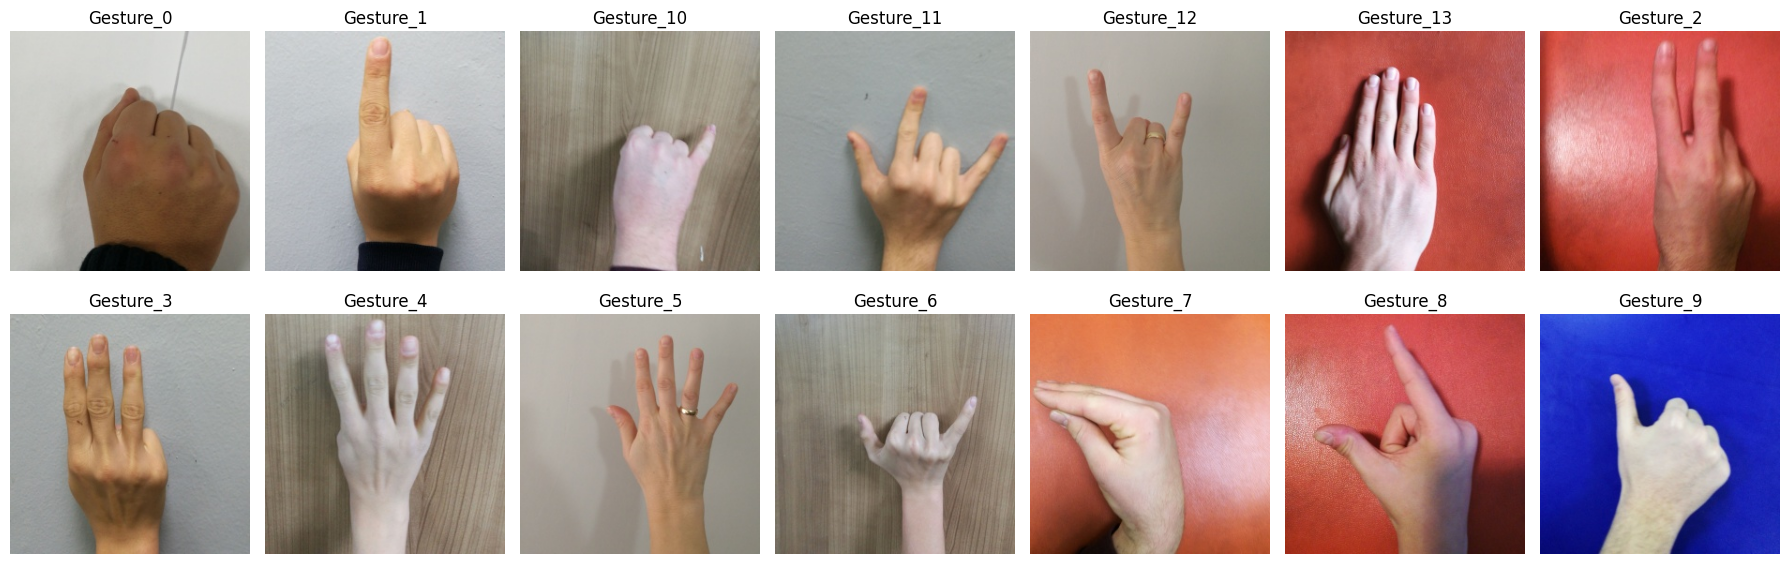

In [ ]:

import matplotlib.pyplot as plt
from PIL import Image
import os

dataset_path = "/content/HG14/HG14/HG14-Hand Gesture"

gestures = sorted(
    [d for d in os.listdir(dataset_path)
     if os.path.isdir(os.path.join(dataset_path, d))]
)

print("Found:", gestures)

fig, axes = plt.subplots(2, 7, figsize=(18, 6))

for ax, gesture in zip(axes.flat, gestures):
    folder = os.path.join(dataset_path, gesture)

    image_file = next(
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    img = Image.open(os.path.join(folder, image_file))

    ax.imshow(img)
    ax.set_title(gesture)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

dataset_path = "/content/HG14/HG14/HG14-Hand Gesture"

for gesture in sorted(os.listdir(dataset_path)):
    folder = os.path.join(dataset_path, gesture)

    if os.path.isdir(folder):
        files = sorted(os.listdir(folder))
        print(f"\n{gesture}:")
        print(files[:20])


Gesture_0:
['0000.jpg', '0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg', '0005.jpg', '0006.jpg', '0007.jpg', '0008.jpg', '0009.jpg', '0010.jpg', '0011.jpg', '0012.jpg', '0013.jpg', '0014.jpg', '0015.jpg', '0016.jpg', '0017.jpg', '0018.jpg', '0019.jpg']

Gesture_1:
['1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg', '1006.jpg', '1007.jpg', '1008.jpg', '1009.jpg', '1010.jpg', '1011.jpg', '1012.jpg', '1013.jpg', '1014.jpg', '1015.jpg', '1016.jpg', '1017.jpg', '1018.jpg', '1019.jpg']

Gesture_10:
['10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg', '10005.jpg', '10006.jpg', '10007.jpg', '10008.jpg', '10009.jpg', '10010.jpg', '10011.jpg', '10012.jpg', '10013.jpg', '10014.jpg', '10015.jpg', '10016.jpg', '10017.jpg', '10018.jpg', '10019.jpg']

Gesture_11:
['11000.jpg', '11001.jpg', '11002.jpg', '11003.jpg', '11004.jpg', '11005.jpg', '11006.jpg', '11007.jpg', '11008.jpg', '11009.jpg', '11010.jpg', '11011.jpg', '11012.jpg', '11013.jpg', '11014.jpg', '11015.jpg'

In [ ]:
import os
from PIL import Image
from collections import Counter

dataset_path = "/content/HG14/HG14/HG14-Hand Gesture"

class_counts = {}
sizes = Counter()

for gesture in sorted(os.listdir(dataset_path)):
    folder = os.path.join(dataset_path, gesture)

    if not os.path.isdir(folder):
        continue

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[gesture] = len(images)

    # Check a few images
    for f in images[:5]:
        img = Image.open(os.path.join(folder, f))
        sizes[img.size] += 1

print("CLASS COUNTS:")
for gesture, count in class_counts.items():
    print(f"{gesture}: {count}")

print("\nIMAGE SIZES:")
print(sizes)

print("\nTOTAL IMAGES:", sum(class_counts.values()))

CLASS COUNTS:
Gesture_0: 1000
Gesture_1: 1000
Gesture_10: 1000
Gesture_11: 1000
Gesture_12: 1000
Gesture_13: 1000
Gesture_2: 1000
Gesture_3: 1000
Gesture_4: 1000
Gesture_5: 1000
Gesture_6: 1000
Gesture_7: 1000
Gesture_8: 1000
Gesture_9: 1000

IMAGE SIZES:
Counter({(256, 256): 70})

TOTAL IMAGES: 14000


In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

dataset_path = "/content/HG14/HG14/HG14-Hand Gesture"

image_paths = []
labels = []

# Keep numerical order: Gesture_0, Gesture_1, ... Gesture_13
class_names = [f"Gesture_{i}" for i in range(14)]

for label, class_name in enumerate(class_names):
    folder = os.path.join(dataset_path, class_name)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(folder, file))
            labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))
print("Classes:", class_names)

Total images: 14000
Total labels: 14000
Classes: ['Gesture_0', 'Gesture_1', 'Gesture_2', 'Gesture_3', 'Gesture_4', 'Gesture_5', 'Gesture_6', 'Gesture_7', 'Gesture_8', 'Gesture_9', 'Gesture_10', 'Gesture_11', 'Gesture_12', 'Gesture_13']


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 9800
Validation: 2100
Testing: 2100


In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(2000)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Pipeline created!")

Pipeline created!


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 1.0


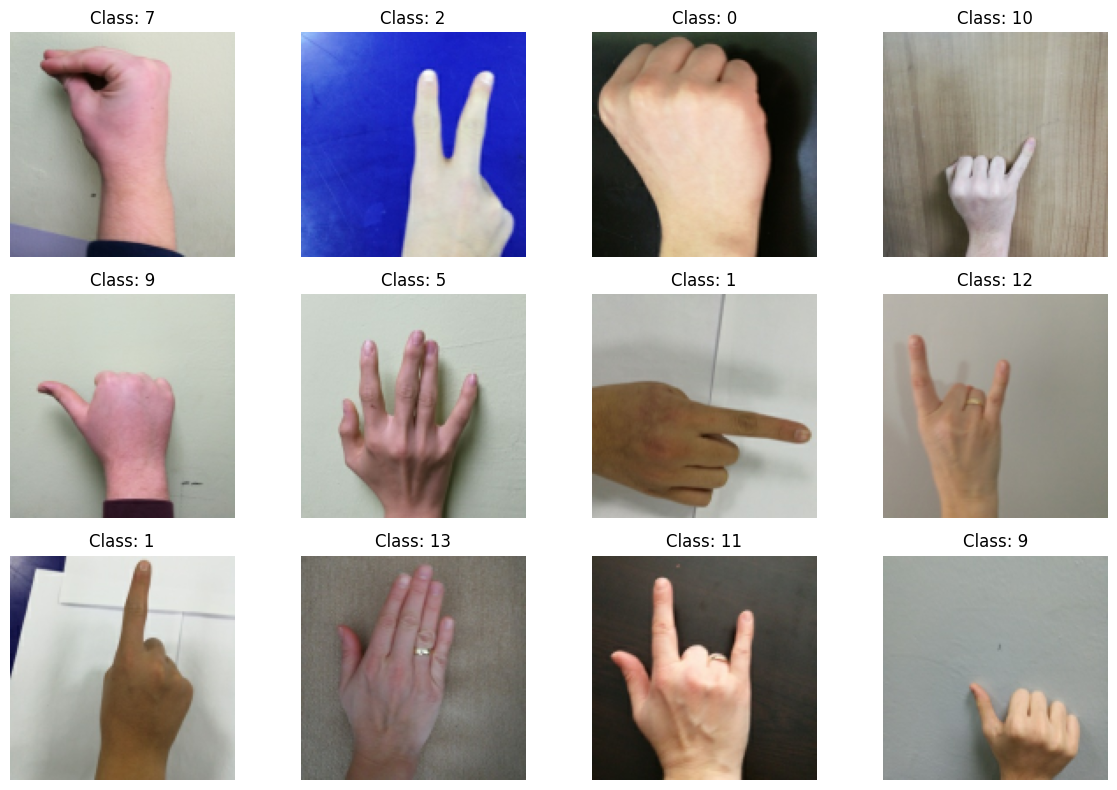

In [ ]:
import matplotlib.pyplot as plt

images, labels_batch = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels_batch.shape)
print("Pixel range:", tf.reduce_min(images).numpy(),
      "to", tf.reduce_max(images).numpy())

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {labels_batch[i].numpy()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
    layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0))
])

In [ ]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

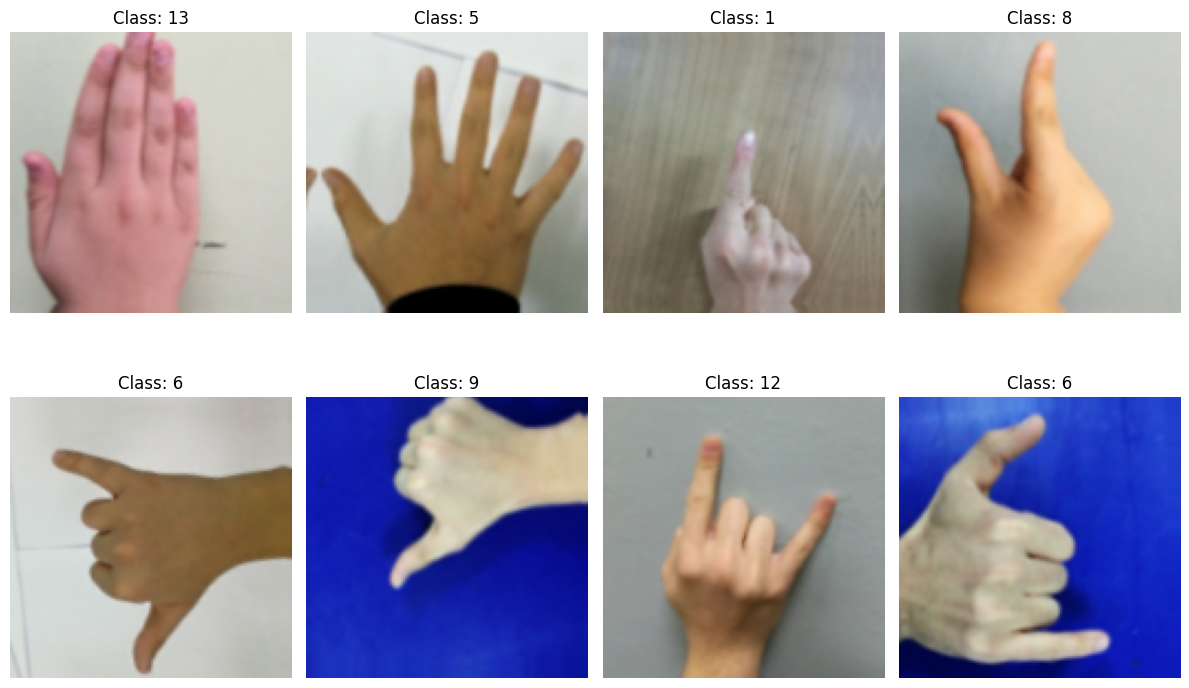

In [ ]:
import matplotlib.pyplot as plt

images, labels_batch = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(8):
    augmented = data_augmentation(images[i:i+1], training=True)

    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented[0])
    plt.title(f"Class: {labels_batch[i].numpy()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input
    layers.Input(shape=(128, 128, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 14 gesture classes
    layers.Dense(14, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,446 (12.61 MB)

 Trainable params: 3,306,446 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # CNN
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(14, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,446 (12.61 MB)

 Trainable params: 3,306,446 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/best_gesture_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1106 - loss: 2.5771 - val_accuracy: 0.2276 - val_loss: 2.3841
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.2165 - loss: 2.3001 - val_accuracy: 0.3519 - val_loss: 2.0335
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3488 - loss: 1.9122 - val_accuracy: 0.5629 - val_loss: 1.3969
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.4379 - loss: 1.6393 - val_accuracy: 0.6186 - val_loss: 1.1839
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.4787 - loss: 1.4808 - val_accuracy: 0.6662 - val_loss: 1.0049
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.5114 - loss: 1.3806 - val_accuracy: 0.7133 - val_loss: 0.9434
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5514 - loss: 1.2774 - val_accuracy: 0.6824 - val_loss: 0.9431
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5780 - loss: 1.2054 - v

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8957 - loss: 0.3267
Test Loss: 0.3267047703266144
Test Accuracy: 0.895714282989502


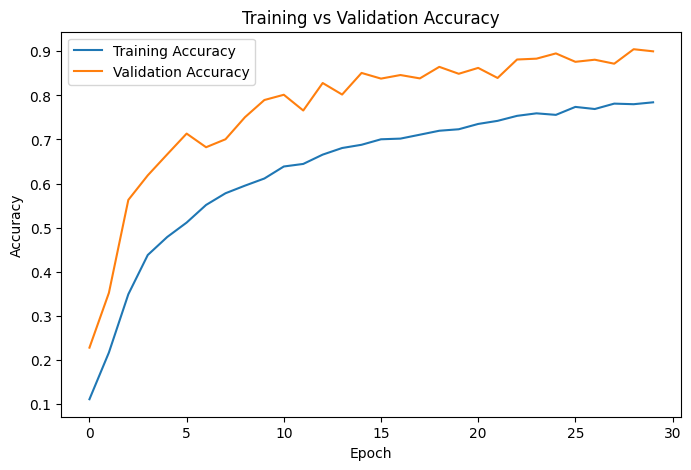

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

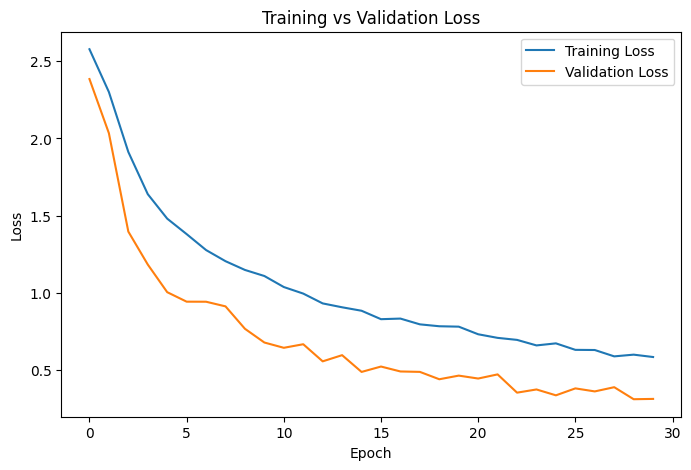

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

Actual labels: (2100,)
Predicted labels: (2100,)


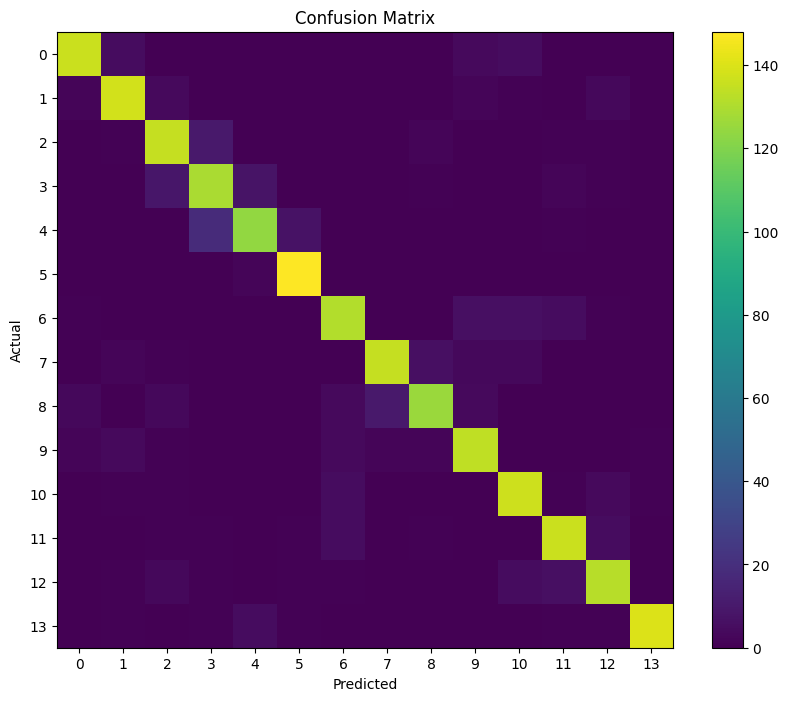

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)

plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.xticks(range(14), range(14))
plt.yticks(range(14), range(14))

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

   Gesture_0     0.9444    0.9067    0.9252       150
   Gesture_1     0.9020    0.9200    0.9109       150
   Gesture_2     0.8544    0.9000    0.8766       150
   Gesture_3     0.8063    0.8600    0.8323       150
   Gesture_4     0.8921    0.8267    0.8581       150
   Gesture_5     0.9367    0.9867    0.9610       150
   Gesture_6     0.8733    0.8733    0.8733       150
   Gesture_7     0.9184    0.9000    0.9091       150
   Gesture_8     0.9130    0.8400    0.8750       150
   Gesture_9     0.8758    0.8933    0.8845       150
  Gesture_10     0.8726    0.9133    0.8925       150
  Gesture_11     0.8889    0.9067    0.8977       150
  Gesture_12     0.8919    0.8800    0.8859       150
  Gesture_13     0.9859    0.9333    0.9589       150

    accuracy                         0.8957      2100
   macro avg     0.8968    0.8957    0.8958      2100
weighted avg     0.8968    0.8957    0.8958      2100



In [ ]:
import matplotlib.pyplot as plt

wrong = np.where(y_true != y_pred)[0]

print("Wrong predictions:", len(wrong))
print("Error rate:", len(wrong) / len(y_true))

Wrong predictions: 219
Error rate: 0.10428571428571429


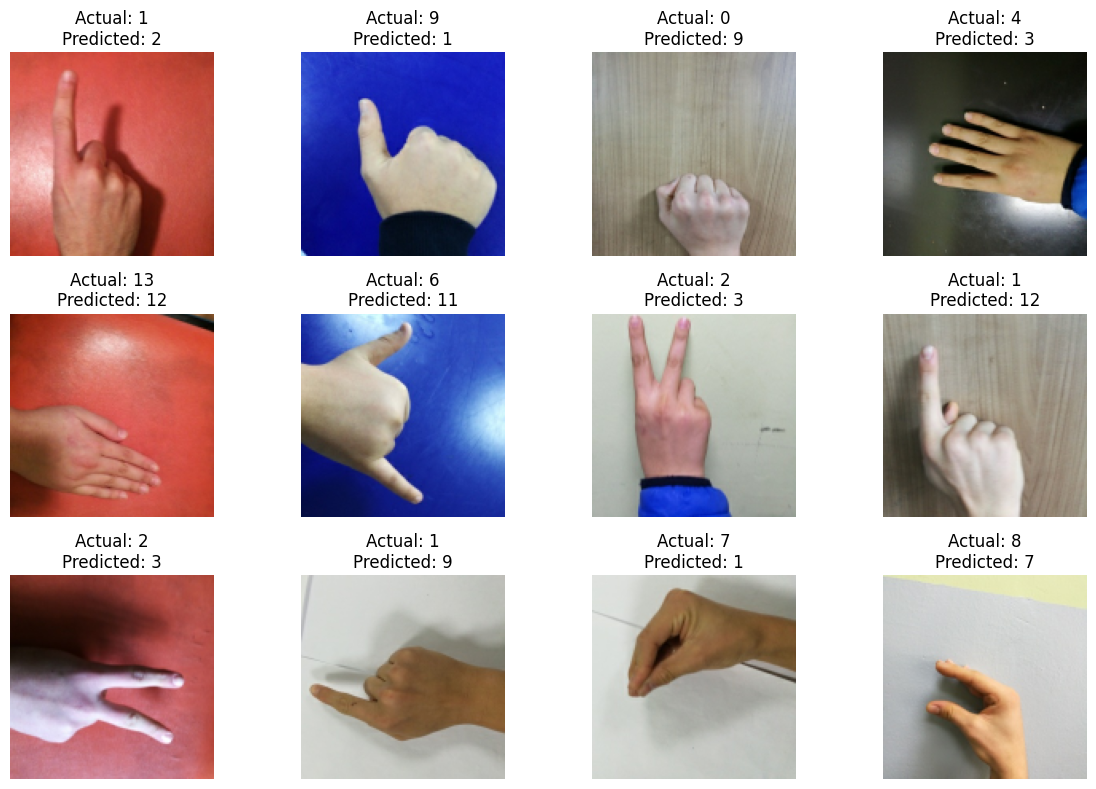

In [ ]:
plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong[:12]):
    image, label = load_image(X_test[idx], y_test[idx])

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        f"Actual: {y_true[idx]}\nPredicted: {y_pred[idx]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

confusions = Counter(
    (actual, predicted)
    for actual, predicted in zip(y_true, y_pred)
    if actual != predicted
)

print("Top 15 confusion pairs:\n")

for (actual, predicted), count in confusions.most_common(15):
    print(
        f"Gesture_{actual} → Gesture_{predicted}: {count} times"
    )

Top 15 confusion pairs:

Gesture_4 → Gesture_3: 18 times
Gesture_2 → Gesture_3: 10 times
Gesture_8 → Gesture_7: 10 times
Gesture_3 → Gesture_2: 9 times
Gesture_3 → Gesture_4: 8 times
Gesture_4 → Gesture_5: 7 times
Gesture_6 → Gesture_9: 6 times
Gesture_6 → Gesture_10: 6 times
Gesture_7 → Gesture_8: 6 times
Gesture_12 → Gesture_11: 6 times
Gesture_6 → Gesture_11: 5 times
Gesture_10 → Gesture_6: 5 times
Gesture_11 → Gesture_12: 5 times
Gesture_0 → Gesture_1: 5 times
Gesture_11 → Gesture_6: 5 times


In [ ]:
from tensorflow.keras import layers, models

model_v2 = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(14, activation="softmax")
])

model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,038 (1.62 MB)

 Trainable params: 424,078 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_v2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_v2 = ModelCheckpoint(
    "/content/best_gesture_model_v2.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop_v2, checkpoint_v2]
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.1483 - loss: 2.5223 - val_accuracy: 0.0724 - val_loss: 4.3464
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.3036 - loss: 1.9911 - val_accuracy: 0.2705 - val_loss: 2.2118
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.5039 - loss: 1.4028 - val_accuracy: 0.3500 - val_loss: 2.2137
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.6716 - loss: 0.9571 - val_accuracy: 0.6429 - val_loss: 1.0634
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.7635 - loss: 0.6816 - val_accuracy: 0.4019 - val_loss: 2.5760
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.8232 - loss: 0.5199 - val_accuracy: 0.7386 - val_loss: 0.7560
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.8559 - loss: 0.4281 - val_accuracy: 0.8319 - val_loss: 0.4754
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8711 - loss: 0.3740 - 

In [ ]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("CNN v2 Test Loss:", test_loss_v2)
print("CNN v2 Test Accuracy:", test_accuracy_v2)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9333 - loss: 0.2039
CNN v2 Test Loss: 0.20391634106636047
CNN v2 Test Accuracy: 0.9333333373069763


In [ ]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy_v2 * 100:.2f}%")
print(f"Test Loss: {test_loss_v2:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9333 - loss: 0.2039
Test Accuracy: 93.33%
Test Loss: 0.2039


In [ ]:
model_v2.save("/content/gesture_model.keras")

In [ ]:
import os

print(os.path.getsize("/content/gesture_model.keras") / (1024**2), "MB")

4.946748733520508 MB


In [ ]:
class_names = [f"Gesture_{i}" for i in range(14)]

print(class_names)

['Gesture_0', 'Gesture_1', 'Gesture_2', 'Gesture_3', 'Gesture_4', 'Gesture_5', 'Gesture_6', 'Gesture_7', 'Gesture_8', 'Gesture_9', 'Gesture_10', 'Gesture_11', 'Gesture_12', 'Gesture_13']


In [ ]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import matplotlib.pyplot as plt

def take_photo(quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');

      button.textContent = 'Capture';
      div.appendChild(video);
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)
    data = eval_js(f'takePhoto({quality})')

    binary = b64decode(data.split(',')[1])
    return cv2.imdecode(
        np.frombuffer(binary, np.uint8),
        cv2.IMREAD_COLOR
    )

<IPython.core.display.Javascript object>

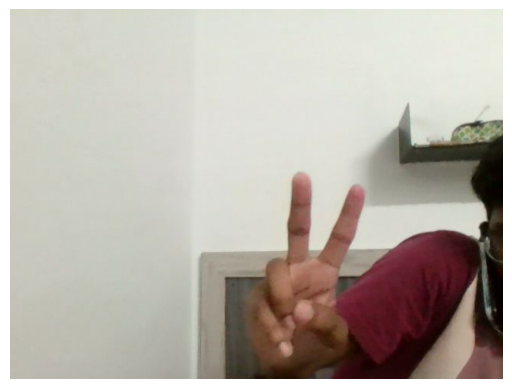

In [ ]:
frame = take_photo()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

In [ ]:
layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0))

<Lambda name=lambda_1, built=False>

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/gesture_model.keras",
    safe_mode=False
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import tensorflow as tf
import numpy as np
import cv2

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/gesture_model.keras",
    safe_mode=False,
    custom_objects={
        "tf": tf
    }
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def clip_tensor(x):
    return tf.clip_by_value(x, 0.0, 1.0)

model = tf.keras.models.load_model(
    "/content/gesture_model.keras",
    safe_mode=False,
    custom_objects={
        "clip_tensor": clip_tensor
    }
)

print("Model loaded!")

Model loaded!


In [ ]:
import tensorflow as tf
import json
import zipfile
import shutil
import os

MODEL_PATH = "/content/gesture_model.keras"
FIXED_PATH = "/content/gesture_model_fixed.keras"

# Read the saved model configuration
with zipfile.ZipFile(MODEL_PATH, "r") as z:
    config = json.loads(z.read("config.json"))

# Remove the problematic Lambda layer
layers_config = config["config"]["layers"]

config["config"]["layers"] = [
    layer for layer in layers_config
    if not (
        layer["class_name"] == "Lambda"
        and layer["config"].get("function", {}).get("class_name") == "__lambda__"
    )
]

# Save modified model config while keeping the ORIGINAL weights
with zipfile.ZipFile(MODEL_PATH, "r") as zin:
    with zipfile.ZipFile(FIXED_PATH, "w") as zout:
        for item in zin.infolist():
            data = zin.read(item.filename)

            if item.filename == "config.json":
                data = json.dumps(config).encode("utf-8")

            zout.writestr(item, data)

print("Fixed model created:", FIXED_PATH)

Fixed model created: /content/gesture_model_fixed.keras


In [ ]:
import zipfile

with zipfile.ZipFile("/content/gesture_model.keras", "r") as z:
    print(z.namelist())

['metadata.json', 'config.json', 'model.weights.h5']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

clean_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(14, activation="softmax")
])

print("Clean architecture created.")

Clean architecture created.


In [ ]:
import zipfile

with zipfile.ZipFile("/content/gesture_model.keras", "r") as z:
    z.extract("model.weights.h5", "/content")

print("Weights extracted!")

Weights extracted!


In [ ]:
clean_model.load_weights("/content/model.weights.h5")

print("Trained weights loaded successfully!")

Trained weights loaded successfully!


In [ ]:
dummy = tf.zeros((1, 128, 128, 3))

output = clean_model(dummy, training=False)

print("Output shape:", output.shape)

Output shape: (1, 14)


In [ ]:
img = cv2.resize(frame, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

prediction = clean_model.predict(img, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0])

print(f"Predicted: Gesture_{predicted_class}")
print(f"Confidence: {confidence * 100:.2f}%")

Predicted: Gesture_4
Confidence: 50.26%


In [ ]:
top5 = np.argsort(prediction[0])[::-1][:5]

for i in top5:
    print(f"Gesture_{i}: {prediction[0][i] * 100:.2f}%")

Gesture_4: 50.26%
Gesture_5: 26.12%
Gesture_3: 9.74%
Gesture_13: 8.54%
Gesture_11: 2.58%


In [ ]:
top5 = np.argsort(prediction[0])[::-1][:5]

for i in top5:
    print(f"Gesture_{i}: {prediction[0][i] * 100:.2f}%")

Gesture_4: 50.26%
Gesture_5: 26.12%
Gesture_3: 9.74%
Gesture_13: 8.54%
Gesture_11: 2.58%


In [ ]:
test_path = X_test[np.where(y_test == 2)[0][0]]

img = tf.io.read_file(test_path)
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, (128, 128))
img = tf.cast(img, tf.float32) / 255.0

test_input = tf.expand_dims(img, 0)

pred = clean_model.predict(test_input, verbose=0)

pred_class = np.argmax(pred[0])
confidence = np.max(pred[0])

print("Actual:    Gesture_2")
print(f"Predicted: Gesture_{pred_class}")
print(f"Confidence: {confidence * 100:.2f}%")

Actual:    Gesture_2
Predicted: Gesture_2
Confidence: 77.96%


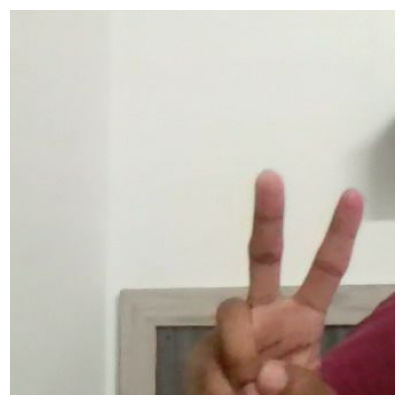

In [ ]:
h, w, _ = frame.shape

crop_size = int(min(h, w) * 0.7)

x1 = (w - crop_size) // 2
y1 = (h - crop_size) // 2
x2 = x1 + crop_size
y2 = y1 + crop_size

hand_crop = frame[y1:y2, x1:x2]

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(hand_crop, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

<IPython.core.display.Javascript object>

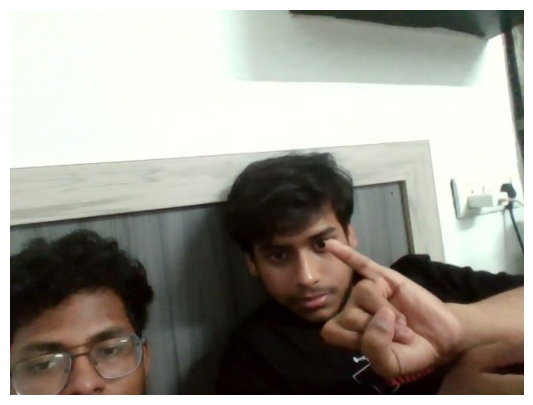

In [ ]:
frame = take_photo()

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
img = cv2.resize(frame, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

prediction = clean_model.predict(img, verbose=0)

top5 = np.argsort(prediction[0])[::-1][:5]

for i in top5:
    print(f"Gesture_{i}: {prediction[0][i] * 100:.2f}%")

Gesture_5: 62.81%
Gesture_4: 19.16%
Gesture_13: 14.63%
Gesture_3: 2.71%
Gesture_11: 0.37%


In [ ]:
frame = take_photo()

img = cv2.resize(frame, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

prediction = clean_model.predict(img, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0])

print(f"Predicted: Gesture_{predicted_class}")
print(f"Confidence: {confidence * 100:.2f}%")

<IPython.core.display.Javascript object>

Predicted: Gesture_5
Confidence: 68.24%


In [ ]:
frame = take_photo()

<IPython.core.display.Javascript object>

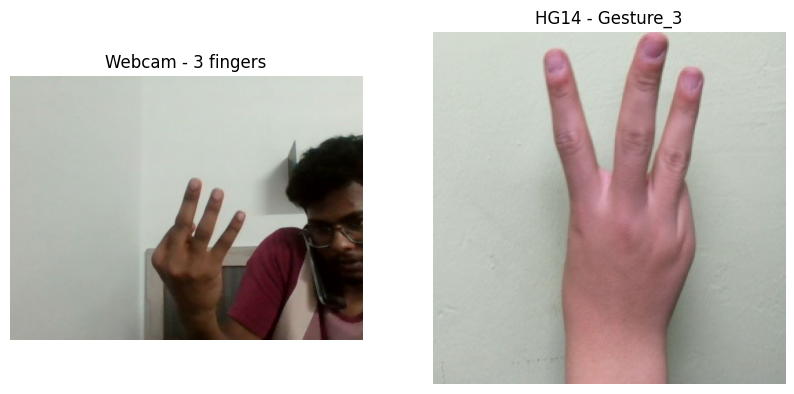

In [ ]:
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

# Webcam image
webcam_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Dataset image
idx = np.where(y_test == 3)[0][0]
path = X_test[idx]

dataset_img = cv2.imread(path)
dataset_img = cv2.cvtColor(dataset_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(webcam_rgb)
plt.title("Webcam - 3 fingers")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dataset_img)
plt.title("HG14 - Gesture_3")
plt.axis("off")

plt.show()

In [ ]:
clean_model.save("/content/gesture_model_clean.keras")
print("Clean model saved!")

Clean model saved!


In [ ]:
import os

webcam_data = "/content/webcam_data"

for i in range(14):
    os.makedirs(f"{webcam_data}/Gesture_{i}", exist_ok=True)

print("Folders created!")

Folders created!


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import os
import time

def collect_gesture(gesture_number, num_images=40, delay=0.15):
    folder = f"/content/webcam_data/Gesture_{gesture_number}"
    os.makedirs(folder, exist_ok=True)

    js = Javascript('''
    async function startCamera() {
        const div = document.createElement('div');
        const video = document.createElement('video');
        const button = document.createElement('button');

        video.width = 640;
        video.height = 480;
        button.textContent = 'Start Capture';

        div.appendChild(video);
        div.appendChild(button);
        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;
        await video.play();

        await new Promise(resolve => button.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        let images = [];

        for (let i = 0; i < NUM_IMAGES; i++) {
            canvas.getContext('2d').drawImage(video, 0, 0);
            images.push(canvas.toDataURL('image/jpeg', 0.85));

            await new Promise(resolve =>
                setTimeout(resolve, DELAY)
            );
        }

        stream.getTracks().forEach(track => track.stop());
        div.remove();

        return images;
    }
    '''.replace("NUM_IMAGES", str(num_images))
       .replace("DELAY", str(int(delay * 1000))))

    display(js)

    data = eval_js("startCamera()")

    for i, image_data in enumerate(data):
        binary = b64decode(image_data.split(',')[1])

        img = cv2.imdecode(
            np.frombuffer(binary, np.uint8),
            cv2.IMREAD_COLOR
        )

        filename = os.path.join(folder, f"{i:03d}.jpg")
        cv2.imwrite(filename, img)

    print(f"Saved {num_images} images to Gesture_{gesture_number}")

In [ ]:
collect_gesture(0, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_0


In [ ]:
collect_gesture(1, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_1


In [ ]:
print("Gesture_1 images:",
      len(os.listdir("/content/webcam_data/Gesture_1")))

Gesture_1 images: 40


In [ ]:
collect_gesture(2, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_2


In [ ]:
collect_gesture(3, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_3


In [ ]:
collect_gesture(4, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_4


In [ ]:
collect_gesture(5, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_5


In [ ]:
collect_gesture(6, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_6


In [ ]:
collect_gesture(7, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_7


In [ ]:
collect_gesture(8, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_8


In [ ]:
collect_gesture(9, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_9


In [ ]:
collect_gesture(10, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_10


In [ ]:
collect_gesture(11, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_11


In [ ]:
collect_gesture(12, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_12


In [ ]:
collect_gesture(13, num_images=40)

<IPython.core.display.Javascript object>

Saved 40 images to Gesture_13


In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

webcam_data = "/content/webcam_data"

paths = []
labels = []

for label in range(14):
    folder = os.path.join(webcam_data, f"Gesture_{label}")

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            paths.append(os.path.join(folder, file))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total images:", len(paths))

Total images: 560


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'best_gesture_model.keras', 'webcam_data', 'HG14', 'gesture_model_clean.keras', 'model.weights.h5', 'hg14-handgesture14-dataset.zip', 'gesture_model_fixed.keras', 'gesture_model.keras', 'best_gesture_model_v2.keras', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_dir = "/content/drive/MyDrive/Hand_Gesture_Project"

os.makedirs(project_dir, exist_ok=True)

print("Project folder created:")
print(project_dir)

Project folder created:
/content/drive/MyDrive/Hand_Gesture_Project


In [ ]:
model_v2.save(
    "/content/drive/MyDrive/Hand_Gesture_Project/gesture_model.keras"
)

print("Model saved!")

Model saved!


In [ ]:
clean_model.save(
    "/content/drive/MyDrive/Hand_Gesture_Project/gesture_model.keras"
)

print("Model saved!")

Model saved!


In [ ]:
import shutil
import os

src = "/content/webcam_data"
dst = "/content/drive/MyDrive/Hand_Gesture_Project/webcam_data"

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("Webcam dataset backed up!")

Webcam dataset backed up!


In [ ]:
print("Project files:")

for item in os.listdir(project_dir):
    print("✓", item)

Project files:
✓ gesture_model.keras
✓ webcam_data


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Hand_Gesture_Project/gesture_model.keras",
    safe_mode=False
)

print("Model loaded!")

Model loaded!


In [ ]:
import os

webcam_data = "/content/drive/MyDrive/Hand_Gesture_Project/webcam_data"

for i in range(14):
    folder = os.path.join(webcam_data, f"Gesture_{i}")
    print(f"Gesture_{i}: {len(os.listdir(folder))} images")

Gesture_0: 40 images
Gesture_1: 40 images
Gesture_2: 40 images
Gesture_3: 40 images
Gesture_4: 40 images
Gesture_5: 40 images
Gesture_6: 40 images
Gesture_7: 40 images
Gesture_8: 40 images
Gesture_9: 40 images
Gesture_10: 40 images
Gesture_11: 40 images
Gesture_12: 40 images
Gesture_13: 40 images


In [ ]:
# Freeze the convolutional feature extractor initially
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last few layers
for layer in model.layers[-5:]:
    layer.trainable = True

# Check what is trainable
for layer in model.layers:
    print(layer.name, layer.trainable)

conv2d_10 False
batch_normalization_4 False
max_pooling2d_10 False
conv2d_11 False
batch_normalization_5 False
max_pooling2d_11 False
conv2d_12 False
batch_normalization_6 False
max_pooling2d_12 False
conv2d_13 False
batch_normalization_7 False
max_pooling2d_13 True
global_average_pooling2d_1 True
dense_6 True
dropout_3 True
dense_7 True


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled for fine-tuning!")

Model compiled for fine-tuning!


In [ ]:
print([x for x in globals() if "ft" in x.lower()])

['early_stop_ft', 'checkpoint_ft']


In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

webcam_data = "/content/drive/MyDrive/Hand_Gesture_Project/webcam_data"

paths = []
labels = []

for label in range(14):
    folder = os.path.join(webcam_data, f"Gesture_{label}")

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            paths.append(os.path.join(folder, file))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total images:", len(paths))

X_ft_train, X_ft_temp, y_ft_train, y_ft_temp = train_test_split(
    paths, labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_ft_temp, y_ft_temp,
    test_size=0.50,
    stratify=y_ft_temp,
    random_state=42
)

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

def load_webcam_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ft = (
    tf.data.Dataset.from_tensor_slices((X_ft_train, y_ft_train))
    .shuffle(400)
    .map(load_webcam_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ft = (
    tf.data.Dataset.from_tensor_slices((X_ft_val, y_ft_val))
    .map(load_webcam_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ft = (
    tf.data.Dataset.from_tensor_slices((X_ft_test, y_ft_test))
    .map(load_webcam_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Train:", len(X_ft_train))
print("Validation:", len(X_ft_val))
print("Test:", len(X_ft_test))
print("Datasets ready!")

Total images: 560
Train: 392
Validation: 84
Test: 84
Datasets ready!


In [ ]:
for layer in model.layers:
    print(layer.name, "→", layer.trainable)

conv2d_10 → False
batch_normalization_4 → False
max_pooling2d_10 → False
conv2d_11 → False
batch_normalization_5 → False
max_pooling2d_11 → False
conv2d_12 → False
batch_normalization_6 → False
max_pooling2d_12 → False
conv2d_13 → False
batch_normalization_7 → False
max_pooling2d_13 → True
global_average_pooling2d_1 → True
dense_6 → True
dropout_3 → True
dense_7 → True


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_ft = model.fit(
    train_ft,
    validation_data=val_ft,
    epochs=20,
    callbacks=[early_stop_ft, checkpoint_ft]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 380ms/step - accuracy: 0.1888 - loss: 5.0527 - val_accuracy: 0.1548 - val_loss: 5.5168
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.1633 - loss: 4.9443 - val_accuracy: 0.1548 - val_loss: 5.4682
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.1582 - loss: 4.9585 - val_accuracy: 0.1548 - val_loss: 5.4218
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.1556 - loss: 5.0290 - val_accuracy: 0.1548 - val_loss: 5.3741
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.1760 - loss: 4.9579 - val_accuracy: 0.1548 - val_loss: 5.3262
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.1735 - loss: 4.9735 - val_accuracy: 0.1548 - val_loss: 5.2810
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.1709 - loss: 4.7647 - val_accuracy: 0.1548 - val_loss: 5.2358
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.1786 - loss: 4.9101 - val_accuracy: 0.1429 -

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Hand_Gesture_Project/gesture_model.keras",
    safe_mode=False
)

print("Original model restored.")

Original model restored.


In [ ]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Hand_Gesture_Project/gesture_model.keras",
    safe_mode=False
)

print("Original CNN restored.")

Original CNN restored.


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
loss, acc = model.evaluate(test_ft, verbose=1)

print(f"Webcam baseline accuracy: {acc * 100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.1190 - loss: 5.4286
Webcam baseline accuracy: 11.90%


In [ ]:
import tensorflow as tf

ft_model = tf.keras.models.clone_model(model)
ft_model.set_weights(model.get_weights())

print("Fine-tuning copy created.")

Fine-tuning copy created.


In [ ]:
webcam_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
])

In [ ]:
def load_webcam_image(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0

    if augment:
        image = webcam_augmentation(image, training=True)
        image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

In [ ]:
train_ft = (
    tf.data.Dataset.from_tensor_slices((X_ft_train, y_ft_train))
    .shuffle(400)
    .map(
        lambda x, y: load_webcam_image(x, y, True),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

val_ft = (
    tf.data.Dataset.from_tensor_slices((X_ft_val, y_ft_val))
    .map(
        lambda x, y: load_webcam_image(x, y, False),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

test_ft = (
    tf.data.Dataset.from_tensor_slices((X_ft_test, y_ft_test))
    .map(
        lambda x, y: load_webcam_image(x, y, False),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

print("Augmented webcam datasets ready!")

Augmented webcam datasets ready!


In [ ]:
for layer in ft_model.layers:
    layer.trainable = False

# Train only the final classifier
ft_model.layers[-1].trainable = True
ft_model.layers[-2].trainable = True
ft_model.layers[-3].trainable = True

In [ ]:
ft_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_stage1 = ft_model.fit(
    train_ft,
    validation_data=val_ft,
    epochs=10,
    callbacks=[early_stop_ft]
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - accuracy: 0.0816 - loss: 10.7731 - val_accuracy: 0.1310 - val_loss: 5.4353
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.0867 - loss: 9.0762 - val_accuracy: 0.0952 - val_loss: 5.3329
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.0612 - loss: 8.3135 - val_accuracy: 0.0833 - val_loss: 5.2524
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - accuracy: 0.0791 - loss: 7.1290 - val_accuracy: 0.0952 - val_loss: 5.1715
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.0791 - loss: 6.4237 - val_accuracy: 0.0952 - val_loss: 5.1133


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_SIZE = (128, 128)
NUM_CLASSES = 14

# Data augmentation
augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
])

# ImageNet pretrained backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# Build model
inputs = layers.Input(shape=(128, 128, 3))

x = augmentation(inputs)

# MobileNetV2 preprocessing: [0,255] -> [-1,1]
x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

transfer_model = Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_tl = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)


Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - accuracy: 0.0933 - loss: 2.8090 - val_accuracy: 0.2229 - val_loss: 2.5006
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.1264 - loss: 2.6235 - val_accuracy: 0.3281 - val_loss: 2.0721
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.1404 - loss: 2.5670 - val_accuracy: 0.3738 - val_loss: 1.8515
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.1480 - loss: 2.5144 - val_accuracy: 0.4171 - val_loss: 1.7988
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.1630 - loss: 2.4851 - val_accuracy: 0.4205 - val_loss: 1.7329
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.1662 - loss: 2.4745 - val_accuracy: 0.4690 - val_loss: 1.5699
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.1682 - loss: 2.4713 - val_accuracy: 0.4595 - val_loss: 1.5904
Epoch 8/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.1660 - loss: 2.4643 - 

In [ ]:
# Unfreeze the last part of MobileNetV2
base_model.trainable = True

# Freeze earlier layers, fine-tune last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Keep BatchNorm layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "functional_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 1,681,294 (6.41 MB)

 Non-trainable params: 594,624 (2.27 MB)

In [ ]:
history_ft = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.1752 - loss: 2.4056 - val_accuracy: 0.5300 - val_loss: 1.3600
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.1932 - loss: 2.3367 - val_accuracy: 0.5648 - val_loss: 1.2662
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.2000 - loss: 2.3111 - val_accuracy: 0.5805 - val_loss: 1.2039
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.2076 - loss: 2.2743 - val_accuracy: 0.5876 - val_loss: 1.1871
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.2136 - loss: 2.2610 - val_accuracy: 0.6233 - val_loss: 1.0764
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.2200 - loss: 2.2364 - val_accuracy: 0.6271 - val_loss: 1.0354
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.2260 - loss: 2.2074 - val_accuracy: 0.6352 - val_loss: 1.0300
Epoch 8/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.2342 - loss: 2.1882 - 

In [ ]:
webcam_test_loss, webcam_test_acc = transfer_model.evaluate(
    test_ft,
    verbose=1
)

print("Webcam Test Accuracy:", webcam_test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.2143 - loss: 3.2666
Webcam Test Accuracy: 0.2142857164144516


In [ ]:
!pip install -q mediapipe

In [ ]:
import mediapipe as mp

print(mp.__version__)
print(mp.tasks)

1.0.1
<module 'mediapipe.tasks.python' from '/usr/local/lib/python3.13/dist-packages/mediapipe/tasks/python/__init__.py'>


In [ ]:
import os
import urllib.request
import mediapipe as mp

model_path = "/content/hand_landmarker.task"

url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(url, model_path)

print("Model ready:", os.path.exists(model_path))

Model ready: True


In [ ]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path="/content/hand_landmarker.task"
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

print("Hand detector ready!")

Hand detector ready!


Hands detected: 1
Original: (480, 640, 3)
Crop: (300, 184, 3)


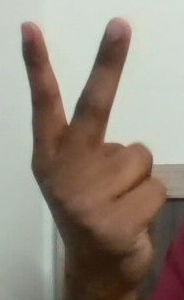

In [ ]:
from PIL import Image
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

sample_path = X_ft_test[0]

image = mp.Image.create_from_file(sample_path)

result = landmarker.detect(image)

print("Hands detected:", len(result.hand_landmarks))

if result.hand_landmarks:
    hand = result.hand_landmarks[0]

    img = cv2.imread(sample_path)
    h, w = img.shape[:2]

    xs = [int(lm.x * w) for lm in hand]
    ys = [int(lm.y * h) for lm in hand]

    padding = 30

    x1 = max(0, min(xs) - padding)
    y1 = max(0, min(ys) - padding)
    x2 = min(w, max(xs) + padding)
    y2 = min(h, max(ys) + padding)

    cropped = img[y1:y2, x1:x2]

    print("Original:", img.shape)
    print("Crop:", cropped.shape)

    cv2_imshow(cropped)
else:
    print("❌ Hand not detected")

In [ ]:
def predict_cropped_image(image_path, model):
    image = cv2.imread(image_path)

    if image is None:
        return None

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = landmarker.detect(mp_image)

    if not result.hand_landmarks:
        return None

    hand = result.hand_landmarks[0]

    h, w = image.shape[:2]

    xs = [int(lm.x * w) for lm in hand]
    ys = [int(lm.y * h) for lm in hand]

    padding = 30

    x1 = max(0, min(xs) - padding)
    y1 = max(0, min(ys) - padding)
    x2 = min(w, max(xs) + padding)
    y2 = min(h, max(ys) + padding)

    cropped = image[y1:y2, x1:x2]

    cropped = cv2.resize(cropped, (128, 128))
    cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    cropped = cropped.astype("float32") / 255.0
    cropped = np.expand_dims(cropped, axis=0)

    prediction = model.predict(cropped, verbose=0)

    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    return predicted_class, confidence

In [ ]:
correct = 0
detected = 0
total = len(X_ft_test)

for path, true_label in zip(X_ft_test, y_ft_test):

    result = predict_cropped_image(path, clean_model)

    if result is None:
        continue

    detected += 1

    predicted_class, confidence = result

    if predicted_class == true_label:
        correct += 1

accuracy = correct / total

print("Total images:", total)
print("Hands detected:", detected)
print("Correct predictions:", correct)
print("Cropped Webcam Accuracy:", accuracy)

Total images: 84
Hands detected: 71
Correct predictions: 16
Cropped Webcam Accuracy: 0.19047619047619047


In [ ]:
import os
import cv2
import mediapipe as mp

cropped_data = "/content/webcam_cropped"

os.makedirs(cropped_data, exist_ok=True)

for label in range(14):
    src_folder = os.path.join(webcam_data, f"Gesture_{label}")
    dst_folder = os.path.join(cropped_data, f"Gesture_{label}")
    os.makedirs(dst_folder, exist_ok=True)

    for file in os.listdir(src_folder):

        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        src_path = os.path.join(src_folder, file)

        image = cv2.imread(src_path)
        if image is None:
            continue

        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        result = landmarker.detect(mp_image)

        if not result.hand_landmarks:
            continue

        hand = result.hand_landmarks[0]

        h, w = image.shape[:2]

        xs = [int(lm.x * w) for lm in hand]
        ys = [int(lm.y * h) for lm in hand]

        padding = 30

        x1 = max(0, min(xs) - padding)
        y1 = max(0, min(ys) - padding)
        x2 = min(w, max(xs) + padding)
        y2 = min(h, max(ys) + padding)

        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (128, 128))

        cv2.imwrite(
            os.path.join(dst_folder, file),
            crop
        )

print("Cropped dataset created.")

Cropped dataset created.


In [ ]:
from sklearn.model_selection import train_test_split
import os
import numpy as np

paths = []
labels = []

for label in range(14):
    folder = os.path.join(cropped_data, f"Gesture_{label}")

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            paths.append(os.path.join(folder, file))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total cropped images:", len(paths))

X_crop_train, X_crop_temp, y_crop_train, y_crop_temp = train_test_split(
    paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_crop_val, X_crop_test, y_crop_val, y_crop_test = train_test_split(
    X_crop_temp,
    y_crop_temp,
    test_size=0.50,
    stratify=y_crop_temp,
    random_state=42
)

print("Train:", len(X_crop_train))
print("Validation:", len(X_crop_val))
print("Test:", len(X_crop_test))

Total cropped images: 507
Train: 354
Validation: 76
Test: 77


In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

webcam_aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
])

def load_crop(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    if augment:
        image = webcam_aug(image, training=True)

    return image, label


train_crop_ds = (
    tf.data.Dataset.from_tensor_slices((X_crop_train, y_crop_train))
    .shuffle(500)
    .map(lambda x, y: load_crop(x, y, True),
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_crop_ds = (
    tf.data.Dataset.from_tensor_slices((X_crop_val, y_crop_val))
    .map(lambda x, y: load_crop(x, y, False),
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_crop_ds = (
    tf.data.Dataset.from_tensor_slices((X_crop_test, y_crop_test))
    .map(lambda x, y: load_crop(x, y, False),
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
# Freeze everything first
for layer in clean_model.layers:
    layer.trainable = False

# Train the last convolutional block and classifier
for layer in clean_model.layers[10:]:
    layer.trainable = True

# Keep BatchNormalization frozen
for layer in clean_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

clean_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

clean_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,038 (1.62 MB)

 Trainable params: 34,702 (135.55 KB)

 Non-trainable params: 390,336 (1.49 MB)

In [ ]:
history_crop = clean_model.fit(
    train_crop_ds,
    validation_data=val_crop_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - accuracy: 0.2034 - loss: 4.5804 - val_accuracy: 0.2895 - val_loss: 3.8891
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.1977 - loss: 4.6226 - val_accuracy: 0.2895 - val_loss: 3.8657
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.2119 - loss: 4.4873 - val_accuracy: 0.2895 - val_loss: 3.8418
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.2316 - loss: 4.3467 - val_accuracy: 0.2895 - val_loss: 3.8185
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.1977 - loss: 4.3113 - val_accuracy: 0.2895 - val_loss: 3.7961
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.2316 - loss: 4.3286 - val_accuracy: 0.2895 - val_loss: 3.7746
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.1977 - loss: 4.3620 - val_accuracy: 0.2895 - val_loss: 3.7517
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.2232 - loss: 4.2338 - val_accuracy: 0.2895 

In [ ]:
from collections import Counter

counts = Counter(labels)

for i in range(14):
    print(f"Gesture_{i}: {counts[i]} images")

print("\nTotal:", len(labels))

Gesture_0: 40 images
Gesture_1: 39 images
Gesture_2: 30 images
Gesture_3: 39 images
Gesture_4: 40 images
Gesture_5: 37 images
Gesture_6: 40 images
Gesture_7: 40 images
Gesture_8: 29 images
Gesture_9: 38 images
Gesture_10: 31 images
Gesture_11: 38 images
Gesture_12: 32 images
Gesture_13: 34 images

Total: 507


In [ ]:
print("Train:", len(X_crop_train))
print("Validation:", len(X_crop_val))
print("Test:", len(X_crop_test))

Train: 354
Validation: 76
Test: 77


In [ ]:
# Start from the MobileNetV2 model
crop_model = transfer_model

# Freeze everything
base_model.trainable = False

# Unfreeze only the last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Keep BatchNorm frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

crop_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

crop_model.summary()

Model: "functional_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 1,212,814 (4.63 MB)

 Non-trainable params: 1,063,104 (4.06 MB)

In [ ]:
history_crop_mobilenet = crop_model.fit(
    train_crop_ds,
    validation_data=val_crop_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.1554 - loss: 2.4862 - val_accuracy: 0.3816 - val_loss: 1.9680
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.1610 - loss: 2.5010 - val_accuracy: 0.3816 - val_loss: 1.9296
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.1667 - loss: 2.4517 - val_accuracy: 0.4211 - val_loss: 1.9376
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.1469 - loss: 2.4620 - val_accuracy: 0.4079 - val_loss: 1.9233
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.1723 - loss: 2.4111 - val_accuracy: 0.4474 - val_loss: 1.8659
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.1554 - loss: 2.4609 - val_accuracy: 0.4342 - val_loss: 1.8167
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.1441 - loss: 2.4553 - val_accuracy: 0.4605 - val_loss: 1.7528
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.1299 - loss: 2.4988 - val_accuracy: 0.421

In [ ]:
print(dataset_path)
print(len(X_train), len(X_val), len(X_test))

/content/HG14/HG14/HG14-Hand Gesture
9800 2100 2100


In [ ]:
# Use the original webcam split
# X_ft_train = 392 webcam training images

combined_paths = np.concatenate([
    X_train,
    X_ft_train
])

combined_labels = np.concatenate([
    y_train,
    y_ft_train
])

print("HG14 training:", len(X_train))
print("Webcam training:", len(X_ft_train))
print("Combined:", len(combined_paths))

HG14 training: 9800
Webcam training: 392
Combined: 10192


In [ ]:
combined_ds = (
    tf.data.Dataset.from_tensor_slices(
        (combined_paths, combined_labels)
    )
    .shuffle(5000)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(32)
    .prefetch(AUTOTUNE)
)

print("Combined dataset ready")

Combined dataset ready


In [ ]:
combined_model = tf.keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(14, activation="softmax")
])

In [ ]:
combined_model.load_weights("/content/model.weights.h5")

In [ ]:
combined_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,038 (1.62 MB)

 Trainable params: 424,078 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Freeze all layers
for layer in combined_model.layers:
    layer.trainable = False

# Unfreeze last convolutional block + classifier
for layer in combined_model.layers[9:]:
    layer.trainable = True

# Keep BatchNorm frozen
for layer in combined_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

combined_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

combined_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,038 (1.62 MB)

 Trainable params: 329,870 (1.26 MB)

 Non-trainable params: 95,168 (371.75 KB)

In [ ]:
history_combined = combined_model.fit(
    combined_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9108 - loss: 0.3714 - val_accuracy: 0.9619 - val_loss: 0.1462
Epoch 2/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9198 - loss: 0.3335 - val_accuracy: 0.9657 - val_loss: 0.1360
Epoch 3/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9250 - loss: 0.3057 - val_accuracy: 0.9700 - val_loss: 0.1283
Epoch 4/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9323 - loss: 0.2872 - val_accuracy: 0.9738 - val_loss: 0.1237
Epoch 5/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9315 - loss: 0.2690 - val_accuracy: 0.9733 - val_loss: 0.1200
Epoch 6/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9359 - loss: 0.2548 - val_accuracy: 0.9752 - val_loss: 0.1159
Epoch 7/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9380 - loss: 0.2431 - val_accuracy: 0.9757 - val_loss: 0.1128
Epoch 8/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9389 - loss: 0.2373 - val

In [ ]:
hg14_test_loss, hg14_test_acc = combined_model.evaluate(
    test_ds,
    verbose=1
)

print("HG14 Test Accuracy:", hg14_test_acc)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9781 - loss: 0.0846
HG14 Test Accuracy: 0.9780952334403992


In [ ]:
webcam_test_loss, webcam_test_acc = combined_model.evaluate(
    test_ft,
    verbose=1
)

print("Webcam Test Accuracy:", webcam_test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.4167 - loss: 1.8676
Webcam Test Accuracy: 0.4166666567325592


In [ ]:
hg14_test_loss, hg14_test_acc = combined_model.evaluate(
    test_ds,
    verbose=1
)

print("HG14 Test Accuracy:", hg14_test_acc)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9781 - loss: 0.0846
HG14 Test Accuracy: 0.9780952334403992


In [ ]:
# Repeat webcam training data 10 times
webcam_paths_over = np.tile(X_ft_train, 10)
webcam_labels_over = np.tile(y_ft_train, 10)

# Combine with HG14
oversampled_paths = np.concatenate([
    X_train,
    webcam_paths_over
])

oversampled_labels = np.concatenate([
    y_train,
    webcam_labels_over
])

print("HG14:", len(X_train))
print("Webcam after oversampling:", len(webcam_paths_over))
print("Total:", len(oversampled_paths))

HG14: 9800
Webcam after oversampling: 3920
Total: 13720


In [ ]:
oversampled_ds = (
    tf.data.Dataset.from_tensor_slices(
        (oversampled_paths, oversampled_labels)
    )
    .shuffle(10000)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(32)
    .prefetch(AUTOTUNE)
)

In [ ]:
oversample_model = tf.keras.models.clone_model(combined_model)
oversample_model.set_weights(combined_model.get_weights())

In [ ]:
for layer in oversample_model.layers:
    layer.trainable = False

for layer in oversample_model.layers[9:]:
    layer.trainable = True

for layer in oversample_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

oversample_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_over = oversample_model.fit(
    oversampled_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - accuracy: 0.8442 - loss: 0.5237 - val_accuracy: 0.9786 - val_loss: 0.0926
Epoch 2/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8526 - loss: 0.4808 - val_accuracy: 0.9767 - val_loss: 0.0952
Epoch 3/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.8633 - loss: 0.4433 - val_accuracy: 0.9757 - val_loss: 0.0968
Epoch 4/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8688 - loss: 0.4182 - val_accuracy: 0.9757 - val_loss: 0.0978
Epoch 5/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8773 - loss: 0.3931 - val_accuracy: 0.9738 - val_loss: 0.0979


In [ ]:
webcam_over_loss, webcam_over_acc = oversample_model.evaluate(
    test_ft,
    verbose=1
)

print("Oversampled Webcam Accuracy:", webcam_over_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.4762 - loss: 1.6166
Oversampled Webcam Accuracy: 0.4761904776096344


In [ ]:
hg14_over_loss, hg14_over_acc = oversample_model.evaluate(
    test_ds,
    verbose=1
)

print("Oversampled HG14 Test Accuracy:", hg14_over_acc)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9776 - loss: 0.0907
Oversampled HG14 Test Accuracy: 0.9776190519332886


In [ ]:
oversample_model.save(
    "/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras"
)

print("Best model saved!")

Best model saved!


In [ ]:
# Save the best model to Google Drive
save_path = "/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras"

oversample_model.save(save_path)

print("Model saved successfully!")
print(save_path)

Model saved successfully!
/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
save_path = "/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras"

oversample_model.save(save_path)

print("Best model saved:", save_path)

Best model saved: /content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras


In [ ]:
import pickle

histories = {
    "combined": history_combined.history,
    "oversample": history_over.history
}

with open(
    "/content/drive/MyDrive/Hand_Gesture_Project/training_histories.pkl",
    "wb"
) as f:
    pickle.dump(histories, f)

print("Training histories saved.")

Training histories saved.


In [ ]:
results_text = """
HAND GESTURE RECOGNITION PROJECT - CURRENT RESULTS

Dataset:
HG14 = 14,000 images
Classes = Gesture_0 to Gesture_13

Original CNN:
HG14 Test Accuracy = ~89.8%
Webcam Test Accuracy = 11.90%

MobileNetV2:
HG14 Validation Accuracy = 72.00%
Webcam Test Accuracy = 21.43%

MediaPipe + Original CNN:
Webcam Test Accuracy = 19.05%
Hands detected = 71/84

Combined HG14 + Webcam:
HG14 Test Accuracy = 97.81%
Webcam Test Accuracy = 41.67%

Webcam Oversampling 10x:
HG14 Test Accuracy = 97.7619%
Webcam Test Accuracy = 47.6190%

BEST MODEL:
oversample_model

NEXT STEP:
Final webcam demo:
Webcam Capture
-> MediaPipe hand detection
-> Automatic hand crop
-> Resize to 128x128
-> final_gesture_model prediction
-> Display Gesture_0 to Gesture_13 + confidence
"""

with open(
    "/content/drive/MyDrive/Hand_Gesture_Project/project_results.txt",
    "w"
) as f:
    f.write(results_text)

print("Project results saved.")

Project results saved.


In [ ]:
import os

project_path = "/content/drive/MyDrive/Hand_Gesture_Project"

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    for file in files:
        print(indent + "    " + file)

Hand_Gesture_Project/
    gesture_model.keras
    gesture_model_finetuned.keras
    final_gesture_model.keras
    training_histories.pkl
    project_results.txt
    webcam_data/
        Gesture_2/
            015.jpg
            016.jpg
            008.jpg
            032.jpg
            012.jpg
            036.jpg
            019.jpg
            020.jpg
            034.jpg
            028.jpg
            003.jpg
            000.jpg
            027.jpg
            024.jpg
            037.jpg
            018.jpg
            029.jpg
            004.jpg
            025.jpg
            010.jpg
            001.jpg
            017.jpg
            022.jpg
            014.jpg
            011.jpg
            026.jpg
            005.jpg
            039.jpg
            035.jpg
            013.jpg
            030.jpg
            007.jpg
            002.jpg
            009.jpg
            021.jpg
            033.jpg
            023.jpg
            038.jpg
            006.jpg
            031.jpg
   

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

model_path = "/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras"

print("Model exists:", os.path.exists(model_path))
print(model_path)

Model exists: True
/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras


In [3]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/Hand_Gesture_Project/final_gesture_model.keras"

final_model = tf.keras.models.load_model(model_path)

print("Model loaded successfully!")
print("Input shape:", final_model.input_shape)
print("Output shape:", final_model.output_shape)

Model loaded successfully!
Input shape: (None, 128, 128, 3)
Output shape: (None, 14)


In [4]:
!pip install -q mediapipe

In [5]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)

MediaPipe version: 1.0.1


In [6]:
import os
import urllib.request

hand_model_path = "/content/hand_landmarker.task"

url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

if not os.path.exists(hand_model_path):
    urllib.request.urlretrieve(url, hand_model_path)

print("Hand model ready:", os.path.exists(hand_model_path))

Hand model ready: True


In [7]:
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path=hand_model_path
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

print("MediaPipe Hand Landmarker ready!")

MediaPipe Hand Landmarker ready!


In [8]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

webcam_data = "/content/drive/MyDrive/Hand_Gesture_Project/webcam_data"

paths = []
labels = []

for label in range(14):
    folder = os.path.join(webcam_data, f"Gesture_{label}")

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            paths.append(os.path.join(folder, file))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total webcam images:", len(paths))

Total webcam images: 560


In [9]:
X_ft_train, X_ft_temp, y_ft_train, y_ft_temp = train_test_split(
    paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_ft_temp,
    y_ft_temp,
    test_size=0.50,
    stratify=y_ft_temp,
    random_state=42
)

print("Webcam train:", len(X_ft_train))
print("Webcam validation:", len(X_ft_val))
print("Webcam test:", len(X_ft_test))

Webcam train: 392
Webcam validation: 84
Webcam test: 84


Actual: Gesture_2
Predicted: Gesture_6
Confidence: 65.67%

Hand crop:


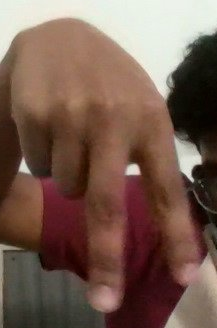

In [10]:
import cv2
import numpy as np
import mediapipe as mp
from google.colab.patches import cv2_imshow

sample_path = X_ft_test[0]

image = cv2.imread(sample_path)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb
)

result = landmarker.detect(mp_image)

if not result.hand_landmarks:
    print("❌ Hand not detected")
else:
    hand = result.hand_landmarks[0]

    h, w = image.shape[:2]

    xs = [int(lm.x * w) for lm in hand]
    ys = [int(lm.y * h) for lm in hand]

    padding = 30

    x1 = max(0, min(xs) - padding)
    y1 = max(0, min(ys) - padding)
    x2 = min(w, max(xs) + padding)
    y2 = min(h, max(ys) + padding)

    crop = image[y1:y2, x1:x2]

    crop_resized = cv2.resize(crop, (128, 128))
    crop_rgb = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB)

    input_image = crop_rgb.astype("float32") / 255.0
    input_image = np.expand_dims(input_image, axis=0)

    prediction = final_model.predict(input_image, verbose=0)

    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    print("Actual:", f"Gesture_{y_ft_test[0]}")
    print("Predicted:", f"Gesture_{predicted_class}")
    print("Confidence:", f"{confidence:.2f}%")

    print("\nHand crop:")
    cv2_imshow(crop)

In [11]:
correct = 0
detected = 0
total = len(X_ft_test)

for path, true_label in zip(X_ft_test, y_ft_test):

    image = cv2.imread(path)

    if image is None:
        continue

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = landmarker.detect(mp_image)

    if not result.hand_landmarks:
        continue

    detected += 1

    hand = result.hand_landmarks[0]

    h, w = image.shape[:2]

    xs = [int(lm.x * w) for lm in hand]
    ys = [int(lm.y * h) for lm in hand]

    padding = 30

    x1 = max(0, min(xs) - padding)
    y1 = max(0, min(ys) - padding)
    x2 = min(w, max(xs) + padding)
    y2 = min(h, max(ys) + padding)

    crop = image[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    crop = cv2.resize(crop, (128, 128))
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    crop = crop.astype("float32") / 255.0
    crop = np.expand_dims(crop, axis=0)

    prediction = final_model.predict(crop, verbose=0)

    predicted_class = np.argmax(prediction[0])

    if predicted_class == true_label:
        correct += 1

print("Total images:", total)
print("Hands detected:", detected)
print("Correct:", correct)
print("Detection-based accuracy:", correct / total)

Total images: 84
Hands detected: 77
Correct: 18
Detection-based accuracy: 0.21428571428571427


In [12]:
import tensorflow as tf
from tensorflow.keras import layers

strong_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.20),
    layers.RandomBrightness(0.15),
])

In [13]:
import os

project_path = "/content/drive/MyDrive/Hand_Gesture_Project"

print(os.listdir(project_path))

['webcam_data', 'gesture_model.keras', 'gesture_model_finetuned.keras', 'training_histories.pkl', 'project_results.txt', 'final_gesture_model.keras']


In [14]:
import os
import urllib.request

url = "https://www.kaggle.com/api/v1/datasets/download/gulerosman/hg14-handgesture14-dataset"

zip_path = "/content/HG14.zip"

urllib.request.urlretrieve(url, zip_path)

print("Downloaded:", os.path.getsize(zip_path) / (1024 * 1024), "MB")

Downloaded: 231.70952129364014 MB


In [15]:
import zipfile
import os

extract_path = "/content/HG14"

with zipfile.ZipFile("/content/HG14.zip", "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


In [16]:
import os

for root, dirs, files in os.walk("/content/HG14"):
    if "Gesture_0" in dirs:
        print("Dataset found at:")
        print(root)
        break

Dataset found at:
/content/HG14/HG14/HG14-Hand Gesture


In [17]:
dataset_path = "/content/HG14/HG14/HG14-Hand Gesture"

for i in range(14):
    folder = os.path.join(dataset_path, f"Gesture_{i}")
    print(f"Gesture_{i}: {len(os.listdir(folder))} files")

Gesture_0: 1000 files
Gesture_1: 1000 files
Gesture_2: 1000 files
Gesture_3: 1000 files
Gesture_4: 1000 files
Gesture_5: 1000 files
Gesture_6: 1000 files
Gesture_7: 1000 files
Gesture_8: 1000 files
Gesture_9: 1000 files
Gesture_10: 1000 files
Gesture_11: 1000 files
Gesture_12: 1000 files
Gesture_13: 1000 files


In [18]:
from sklearn.model_selection import train_test_split
import os
import numpy as np

image_paths = []
labels = []

class_names = [f"Gesture_{i}" for i in range(14)]

for label, class_name in enumerate(class_names):
    folder = os.path.join(dataset_path, class_name)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(folder, file))
            labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total HG14 images:", len(image_paths))

# Same split as our original experiment
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("HG14 train:", len(X_train))
print("HG14 validation:", len(X_val))
print("HG14 test:", len(X_test))

Total HG14 images: 14000
HG14 train: 9800
HG14 validation: 2100
HG14 test: 2100


In [19]:
# Webcam training images ×20
webcam_paths_over_20 = np.tile(X_ft_train, 20)
webcam_labels_over_20 = np.tile(y_ft_train, 20)

# Combine HG14 + oversampled webcam
exp1_paths = np.concatenate([
    X_train,
    webcam_paths_over_20
])

exp1_labels = np.concatenate([
    y_train,
    webcam_labels_over_20
])

print("HG14:", len(X_train))
print("Webcam ×20:", len(webcam_paths_over_20))
print("Total:", len(exp1_paths))

HG14: 9800
Webcam ×20: 7840
Total: 17640


In [20]:
from tensorflow.keras import layers

strong_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.20),
    layers.RandomBrightness(0.15),
])

In [21]:
def load_and_augment(path, label):
    image, label = load_image(path, label)
    image = strong_augmentation(image, training=True)
    return image, label

In [22]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

print("AUTOTUNE ready")

AUTOTUNE ready


In [23]:
import tensorflow as tf
import numpy as np
import os

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


print("Preprocessing functions ready.")

Preprocessing functions ready.


In [24]:
exp1_ds = (
    tf.data.Dataset.from_tensor_slices((exp1_paths, exp1_labels))
    .shuffle(15000, seed=42)
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Experiment 1 dataset ready.")

Experiment 1 dataset ready.


In [25]:
# Clone current best model
exp1_model = tf.keras.models.clone_model(final_model)

# Copy the trained weights
exp1_model.set_weights(final_model.get_weights())

# Freeze everything first
for layer in exp1_model.layers:
    layer.trainable = False

# Unfreeze deeper layers
for layer in exp1_model.layers[6:]:
    layer.trainable = True

# Keep Batch Normalization frozen
for layer in exp1_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Compile with a very small learning rate
exp1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

exp1_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,038 (1.62 MB)

 Trainable params: 403,726 (1.54 MB)

 Non-trainable params: 21,312 (83.25 KB)

In [26]:
exp1_val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [27]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
!nvidia-smi

Tue Sep 15 04:28:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             29W /   70W |     905MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

exp1_checkpoint = ModelCheckpoint(
    "/content/exp1_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

exp1_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_exp1 = exp1_model.fit(
    exp1_ds,
    validation_data=exp1_val_ds,
    epochs=20,
    callbacks=[
        exp1_checkpoint,
        exp1_early_stop
    ]
)

Epoch 1/20
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.0745 - loss: 140.9037
Epoch 1: val_accuracy improved from None to 0.98238, saving model to /content/exp1_best.keras

Epoch 1: finished saving model to /content/exp1_best.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 121s 211ms/step - accuracy: 0.0770 - loss: 111.4249 - val_accuracy: 0.9824 - val_loss: 0.0787
Epoch 2/20
551/552 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.0780 - loss: 33.9664
Epoch 2: val_accuracy did not improve from 0.98238
552/552 ━━━━━━━━━━━━━━━━━━━━ 113s 204ms/step - accuracy: 0.0759 - loss: 26.9619 - val_accuracy: 0.9748 - val_loss: 0.0978
Epoch 3/20
551/552 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.0796 - loss: 17.1444
Epoch 3: val_accuracy did not improve from 0.98238
552/552 ━━━━━━━━━━━━━━━━━━━━ 111s 201ms/step - accuracy: 0.0785 - loss: 15.9743 - val_accuracy: 0.9733 - val_loss: 0.1044
Epoch 4/20
551/552 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.0831 - loss: 13.6529
Epoch 4: val_accurac

In [31]:
batch_images, batch_labels = next(iter(exp1_ds))

print("Images shape:", batch_images.shape)
print("Images dtype:", batch_images.dtype)
print("Images min:", tf.reduce_min(batch_images).numpy())
print("Images max:", tf.reduce_max(batch_images).numpy())

print("Labels shape:", batch_labels.shape)
print("Labels:", batch_labels[:20].numpy())

Images shape: (32, 128, 128, 3)
Images dtype: <dtype: 'float32'>
Images min: 0.0
Images max: 35.512985
Labels shape: (32,)
Labels: [ 2  5  2 11  8  8  4 12  3 11  6  2 12  7  3  5  0 10 13  1]


In [32]:
print("Unique labels:", np.unique(batch_labels.numpy()))

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


In [34]:
exp1_model = tf.keras.models.load_model("/content/exp1_best.keras")

print(exp1_model.input_shape)
print(exp1_model.output_shape)

(None, 128, 128, 3)
(None, 14)


In [35]:
webcam_test_ds = (
    tf.data.Dataset.from_tensor_slices((X_ft_test, y_ft_test))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(32)
    .prefetch(AUTOTUNE)
)

In [36]:
loss, acc = exp1_model.evaluate(webcam_test_ds, verbose=1)

print(f"Experiment 1 Webcam Test Accuracy: {acc * 100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 654ms/step - accuracy: 0.5119 - loss: 1.6332
Experiment 1 Webcam Test Accuracy: 51.19%
